# 02 — Cleaning, deduplication & segmentation

Création du corpus propre et des segments utilisés pour l’ABSA.

In [1]:
from pathlib import Path
import sys, json, warnings
warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
while not (ROOT / "config" / "project_config.json").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: C:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first


## 1. Paramètres

In [2]:
CHUNKSIZE = 100_000
MIN_WORDS_FLAG = 5
CLEAN_DIR = ROOT / "data" / "interim" / "clean_review_parts"
DUP_DIR = ROOT / "data" / "interim" / "duplicate_parts"
SEG_DIR = ROOT / "data" / "interim" / "segment_parts"

for d in [CLEAN_DIR, DUP_DIR, SEG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    for old in d.glob("*.parquet"):
        old.unlink()
print("Output folders reset.")

Output folders reset.


## 2. Métadonnées produit

In [3]:
from src.io_utils import read_products
products = read_products(ROOT)
product_cols = [
    "product_id", "product_name", "brand_name", "primary_category", "secondary_category",
    "tertiary_category", "ingredients", "price_usd", "rating", "reviews", "highlights"
]
product_meta = products[product_cols].copy()
product_meta = product_meta.rename(columns={"rating": "catalog_rating", "reviews": "catalog_reviews", "price_usd": "catalog_price_usd"})
print("Product metadata rows:", len(product_meta))
display(product_meta.head())

Product metadata rows: 8494


,product_id,product_name,brand_name,primary_category,secondary_category,tertiary_category,ingredients,catalog_price_usd,catalog_rating,catalog_reviews,highlights
0,P473671,Fragrance Discovery Set,19-69,Fragrance,Value & Gift Sets,Perfume Gift Sets,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,3.6364,11.0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen..."
1,P473668,La Habana Eau de Parfum,19-69,Fragrance,Women,Perfume,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,4.1538,13.0,"['Unisex/ Genderless Scent', 'Layerable Scent'..."
2,P473662,Rainbow Bar Eau de Parfum,19-69,Fragrance,Women,Perfume,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,4.2500,16.0,"['Unisex/ Genderless Scent', 'Layerable Scent'..."
3,P473660,Kasbah Eau de Parfum,19-69,Fragrance,Women,Perfume,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,4.4762,21.0,"['Unisex/ Genderless Scent', 'Layerable Scent'..."
4,P473658,Purple Haze Eau de Parfum,19-69,Fragrance,Women,Perfume,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,3.2308,13.0,"['Unisex/ Genderless Scent', 'Layerable Scent'..."


## 3. Nettoyage et déduplication

Traitement par chunks de 100 000 lignes. Les doublons sont détectés à partir du texte normalisé.

In [4]:
from src.io_utils import iter_review_chunks
from src.text_utils import normalize_whitespace, normalize_for_dedup
from tqdm.auto import tqdm

review_usecols = [
    "author_id", "rating", "is_recommended", "helpfulness", "total_feedback_count",
    "total_neg_feedback_count", "total_pos_feedback_count", "submission_time",
    "review_text", "review_title", "skin_tone", "eye_color", "skin_type", "hair_color",
    "product_id", "product_name", "brand_name", "price_usd"
]

seen_hashes = set()
summary_rows = []
part_id = 0

for source_file, chunk in tqdm(iter_review_chunks(ROOT, chunksize=CHUNKSIZE, usecols=review_usecols)):
    chunk["review_id"] = source_file.replace(".csv", "") + "::" + chunk["source_row"].astype(str)
    chunk["review_text"] = chunk["review_text"].map(normalize_whitespace)
    blank = chunk["review_text"].eq("")

    norm = chunk["review_text"].map(normalize_for_dedup)
    hashes = pd.util.hash_pandas_object(norm, index=False).astype("uint64")
    chunk["normalized_text_hash"] = hashes

    seen_before = hashes.map(lambda h: int(h) in seen_hashes)
    dup_within = hashes.duplicated(keep="first")
    duplicate = (~blank) & (seen_before | dup_within)

    dup_part = chunk.loc[duplicate].copy()
    if len(dup_part):
        dup_part.to_parquet(DUP_DIR / f"part_{part_id:04d}.parquet", index=False)

    keep = (~blank) & (~duplicate)
    clean = chunk.loc[keep].copy()
    seen_hashes.update(int(h) for h in clean["normalized_text_hash"].tolist())

    # Join product catalog. Catalog values are authoritative where available.
    clean = clean.merge(product_meta, on="product_id", how="left", suffixes=("_review", "_catalog"), validate="many_to_one")
    clean["submission_time"] = pd.to_datetime(clean["submission_time"], errors="coerce")
    clean["review_word_count"] = clean["review_text"].str.findall(r"\b\w+\b").str.len().astype("int32")
    clean["is_short_review"] = clean["review_word_count"] < MIN_WORDS_FLAG
    clean["product_matched"] = clean["primary_category"].notna()

    # Keep the skincare corpus for this project. Save non-skincare diagnostic count in summary.
    skincare = clean["primary_category"].eq("Skincare")
    clean_skincare = clean.loc[skincare].copy()
    clean_skincare.to_parquet(CLEAN_DIR / f"part_{part_id:04d}.parquet", index=False)

    summary_rows.append({
        "source_file": source_file,
        "input_rows": len(chunk),
        "blank_rows": int(blank.sum()),
        "duplicate_rows": int(duplicate.sum()),
        "kept_before_category_filter": int(keep.sum()),
        "kept_skincare": len(clean_skincare),
        "unmatched_product": int((keep & ~chunk["product_id"].isin(product_meta["product_id"])).sum()),
    })
    part_id += 1

clean_summary = pd.DataFrame(summary_rows)
display(clean_summary)
clean_summary.to_csv(TABLE_DIR / "cleaning_summary_by_chunk.csv", index=False)
print("Total input:", clean_summary["input_rows"].sum())
print("Total blank:", clean_summary["blank_rows"].sum())
print("Total duplicates removed:", clean_summary["duplicate_rows"].sum())
print("Total clean skincare:", clean_summary["kept_skincare"].sum())

15it [04:12, 16.81s/it]


,source_file,input_rows,blank_rows,duplicate_rows,kept_before_category_filter,kept_skincare,unmatched_product
0,reviews_0-250.csv,100000,294,12082,87624,87624,0
1,reviews_0-250.csv,100000,174,22731,77095,77095,0
2,reviews_0-250.csv,100000,114,15460,84426,84426,0
3,reviews_0-250.csv,100000,100,28477,71423,71423,0
4,reviews_0-250.csv,100000,175,3550,96275,96275,0
5,reviews_0-250.csv,100000,142,10586,89272,89272,0
6,reviews_0-250.csv,2130,0,4,2126,2126,0
7,reviews_250-500.csv,100000,82,13531,86387,86387,0
8,reviews_250-500.csv,100000,87,7256,92657,92657,0
9,reviews_250-500.csv,6725,3,36,6686,6686,0


Total input: 1094411
Total blank: 1444
Total duplicates removed: 123950
Total clean skincare: 969017


## 4. Lignes supprimées

,rows
blank,1444
duplicates,123950
kept_skincare,969017


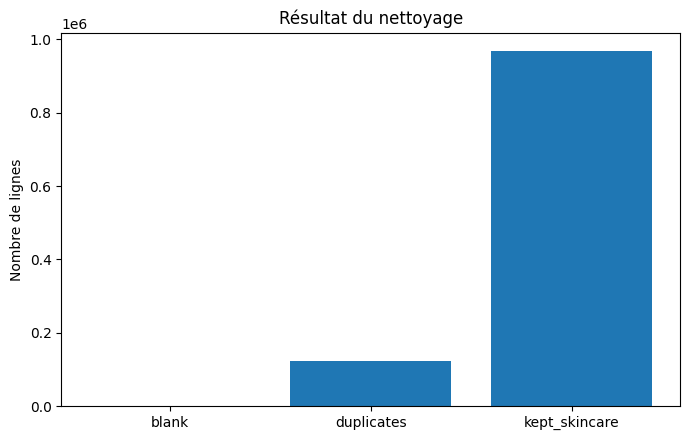

In [5]:
totals = pd.Series({
    "blank": clean_summary["blank_rows"].sum(),
    "duplicates": clean_summary["duplicate_rows"].sum(),
    "kept_skincare": clean_summary["kept_skincare"].sum(),
})
display(totals.to_frame("rows"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(totals.index, totals.values)
ax.set_title("Résultat du nettoyage")
ax.set_ylabel("Nombre de lignes")
fig.tight_layout()
fig.savefig(FIG_DIR / "20_cleaning_outcome.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Contrôle du corpus propre

In [6]:
from src.io_utils import list_parquet_parts
clean_parts = list_parquet_parts(CLEAN_DIR)
assert clean_parts, "Aucun parquet propre créé."

sample_clean = pd.read_parquet(clean_parts[0]).head(10)
display(sample_clean[["review_id", "review_text", "product_id", "product_name_catalog", "brand_name_catalog", "skin_type", "primary_category"]])
print("Number of clean parquet parts:", len(clean_parts))

,review_id,review_text,product_id,product_name_catalog,brand_name_catalog,skin_type,primary_category
0,reviews_0-250::0,I use this with the Nudestix “Citrus Clean Bal...,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,dry,Skincare
1,reviews_0-250::1,I bought this lip mask after reading the revie...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,NaN,Skincare
2,reviews_0-250::2,My review title says it all! I get so excited ...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,dry,Skincare
3,reviews_0-250::3,I’ve always loved this formula for a long time...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,combination,Skincare
4,reviews_0-250::4,"If you have dry cracked lips, this is a must h...",P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,combination,Skincare
5,reviews_0-250::5,The scent isn’t my favourite but it works grea...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,normal,Skincare
6,reviews_0-250::6,I’ll give this 2 stars for nice packaging and ...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,combination,Skincare
7,reviews_0-250::7,I use this at night or while I’m putting makeu...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,combination,Skincare
8,reviews_0-250::8,I love this stuff. I first had the sample size...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,normal,Skincare
9,reviews_0-250::9,I purchased the Sweet Candy scent at my local ...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,normal,Skincare


Number of clean parquet parts: 15


## 6. Segmentation

Découpage par ponctuation. Un segment peut contenir plusieurs aspects.

In [7]:
from src.text_utils import sentence_split_series

seg_summary = []
for i, path in enumerate(tqdm(clean_parts)):
    df = pd.read_parquet(path)
    keep_cols = [
        "review_id", "author_id", "product_id", "product_name_catalog", "brand_name_catalog",
        "skin_type", "rating", "is_recommended", "submission_time", "primary_category",
        "secondary_category", "tertiary_category", "review_text"
    ]
    df = df[[c for c in keep_cols if c in df.columns]].copy()
    seg = sentence_split_series(df, text_col="review_text")
    seg["is_short_segment"] = seg["segment_word_count"] < MIN_WORDS_FLAG
    seg.to_parquet(SEG_DIR / f"part_{i:04d}.parquet", index=False)
    seg_summary.append({
        "clean_reviews": df["review_id"].nunique(),
        "segments": len(seg),
        "short_segments": int(seg["is_short_segment"].sum()),
    })

seg_summary = pd.DataFrame(seg_summary)
display(seg_summary)
print("Total segments:", seg_summary["segments"].sum())
print("Short segments:", seg_summary["short_segments"].sum())
seg_summary.to_csv(TABLE_DIR / "segmentation_summary.csv", index=False)

100%|██████████| 15/15 [02:29<00:00,  9.94s/it]


,clean_reviews,segments,short_segments
0,87624,380823,43097
1,77095,320192,35782
2,84426,365456,38484
3,71423,314950,32540
4,96275,417308,42593
5,89272,419767,41497
6,2126,9292,1050
7,86387,386978,37735
8,92657,425296,41112
9,6686,29480,2860


Total segments: 4314133
Short segments: 441157


## 7. Longueur des segments

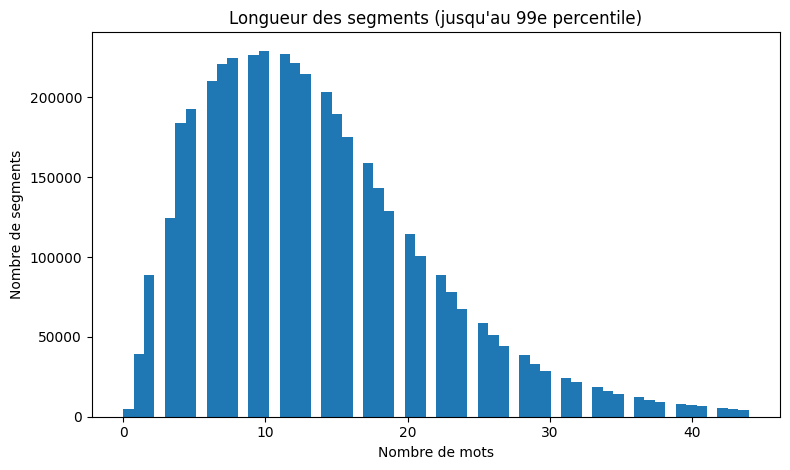

,segment_word_count
count,4.314133e+06
mean,1.395123e+01
std,9.170285e+00
min,0.000000e+00
50%,1.200000e+01
75%,1.800000e+01
90%,2.500000e+01
95%,3.000000e+01
99%,4.400000e+01
max,3.800000e+02


In [8]:
segment_parts = list_parquet_parts(SEG_DIR)
lengths = []
for p in segment_parts:
    lengths.append(pd.read_parquet(p, columns=["segment_word_count"]))
lengths = pd.concat(lengths, ignore_index=True)["segment_word_count"]
upper = max(10, lengths.quantile(.99))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(lengths[lengths <= upper], bins=60)
ax.set_title("Longueur des segments (jusqu'au 99e percentile)")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Nombre de segments")
fig.tight_layout()
fig.savefig(FIG_DIR / "21_segment_length_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

display(lengths.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame("segment_word_count"))

## 8. Exemples

In [9]:
ex = pd.read_parquet(segment_parts[0], columns=["review_id", "segment_id", "segment_text", "segment_word_count"]).head(30)
display(ex)

,review_id,segment_id,segment_text,segment_word_count
0,reviews_0-250::0,reviews_0-250::0::s0,I use this with the Nudestix “Citrus Clean Bal...,25
1,reviews_0-250::0,reviews_0-250::0::s1,The make-up melt is oil based and removes all ...,15
2,reviews_0-250::0,reviews_0-250::0::s2,"I follow-up with this water based cleanser, an...",23
3,reviews_0-250::0,reviews_0-250::0::s3,"It leaves the skin gently cleansed, but withou...",11
4,reviews_0-250::0,reviews_0-250::0::s4,10/10 recommend combining with the make-up melt.,9
5,reviews_0-250::0,reviews_0-250::0::s5,It’s perfection!,3
6,reviews_0-250::1,reviews_0-250::1::s0,I bought this lip mask after reading the revie...,12
7,reviews_0-250::1,reviews_0-250::1::s1,"Unfortunately, it did not meet my expectations...",16
8,reviews_0-250::2,reviews_0-250::2::s0,My review title says it all!,6
9,reviews_0-250::2,reviews_0-250::2::s1,I get so excited to get into bed and apply thi...,13


## Sorties

- `data/interim/clean_review_parts/*.parquet`
- `data/interim/duplicate_parts/*.parquet`
- `data/interim/segment_parts/*.parquet`